# Baseline Model Selection and Justification

This notebook is the **baseline-model milestone** for the project, but it also takes a critical step back and asks whether the first baseline formulation was actually the right one.

The proposal asks whether **urban expansion / night-light changes** can help explain or predict **future metro-level economic activity**. The `MODELING_NEXT_STEPS.md` file turns that idea into a Stage 3 panel-regression baseline with:

- lagged predictors
- metro fixed effects
- train / validation / test split by year
- comparison across interpretable and nonlinear models

A research-scientist reading of the first baseline revealed two weaknesses:

1. it did **not** fully use the problem's forecasting structure, because it omitted lagged economic-growth terms that are natural baselines for future change prediction;
2. it relied heavily on a **single validation year (`2019`)**, which is noisy for a small panel.

So this revised notebook does two things:

- it builds a stronger, still-defensible baseline using **lagged raw satellite summaries + lagged economic dynamics**;
- it evaluates models with both the official `2019` validation split **and** a small **rolling-origin validation check** on earlier train years.

This notebook still does **not** answer the full proposal, because the planned **GHSL-derived built-up footprint features** are not yet available. Instead, it provides the best current answer to a narrower milestone question:

> **How far can we get with lagged raw satellite summaries and standard tabular baselines before the richer spatial features are ready?**

## Project Status Snapshot

This notebook is easiest to read in the context of the **overall project plan** rather than as a standalone modeling exercise.

| Project component | Current status | What is already known |
| --- | --- | --- |
| **Data pipeline** | Completed | Satellite imagery, economic indicators, and the unified metro-year panel are already built. |
| **EDA** | Completed | Raw pixel summaries are weak across pooled cities, but within-metro temporal structure is meaningful. |
| **Raw-pixel baseline modeling** | Completed in this notebook | We now have a defensible benchmark before richer spatial features exist. |
| **GHSL / built-up segmentation and spatial feature extraction** | Not yet completed | This is still the key missing ingredient for answering the full proposal. |
| **Final scientific comparison** | Pending | The real test will be whether built-up / urban-form features outperform the raw-pixel baseline established here. |

So the role of this notebook is very specific:

- it is **not** the final answer to the proposal;
- it **is** the benchmark that later GHSL-derived features will need to beat;
- it should therefore be evaluated on **clarity, honesty, and robustness**, not just on getting the highest possible score.

In [1]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from IPython.display import display
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

warnings.filterwarnings(
    "ignore",
    message="Skipping features without any observed values",
    category=UserWarning,
)

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.titlesize"] = 17
plt.rcParams["axes.labelsize"] = 12
plt.rcParams["axes.titleweight"] = "semibold"
plt.rcParams["legend.frameon"] = False
plt.rcParams["figure.dpi"] = 120
plt.rcParams["axes.facecolor"] = "#fcfcfd"
plt.rcParams["grid.color"] = "#d0d7de"
plt.rcParams["grid.linewidth"] = 1.0
plt.rcParams["axes.edgecolor"] = "#c7ccd1"

pd.set_option("display.max_columns", 100)

DATA_PATH = Path("data/modeling/panel_features.csv")

model_palette = {
    "Linear Regression (fixed effects)": "#64748b",
    "Random Forest Regressor": "#0f766e",
    "Gradient Boosting Regressor": "#2563eb",
}

diagnostic_palette = {
    "Current Linear Baseline": "#94a3b8",
    "Enhanced Linear Baseline": "#0f766e",
}

year_palette = {
    2021: "#6d28d9",
    2022: "#0f766e",
    2023: "#d97706",
}

group_palette = {
    "Lagged economic growth": "#0f766e",
    "Lagged economic levels": "#2563eb",
    "Lagged satellite summaries": "#64748b",
}


def display_table(df, caption=None, precision=3, left_align=None, highlight_rows=None):
    styler = df.style.format(precision=precision)
    if caption:
        styler = styler.set_caption(caption)
    styler = styler.set_table_styles(
        [
            {
                "selector": "caption",
                "props": [
                    ("caption-side", "top"),
                    ("text-align", "left"),
                    ("font-size", "14px"),
                    ("font-weight", "600"),
                    ("color", "#0f172a"),
                    ("margin-bottom", "6px"),
                ],
            },
            {
                "selector": "th",
                "props": [
                    ("background-color", "#eef2f7"),
                    ("color", "#0f172a"),
                    ("font-weight", "600"),
                    ("border", "1px solid #d7dce2"),
                    ("padding", "7px 10px"),
                    ("text-align", "left"),
                ],
            },
            {
                "selector": "td",
                "props": [
                    ("border", "1px solid #e5e7eb"),
                    ("padding", "7px 10px"),
                    ("vertical-align", "top"),
                    ("white-space", "normal"),
                ],
            },
        ]
    )
    if left_align is not None:
        styler = styler.set_properties(subset=left_align, **{"text-align": "left"})
    else:
        styler = styler.set_properties(**{"text-align": "left"})
    if highlight_rows is not None:
        def _highlight(row):
            if row.name in highlight_rows:
                return ["background-color: #ecfdf5; font-weight: 600"] * len(row)
            return [""] * len(row)
        styler = styler.apply(_highlight, axis=1)
    try:
        styler = styler.hide(axis="index")
    except Exception:
        try:
            styler = styler.hide_index()
        except Exception:
            pass
    display(styler)

## 1. Baseline Model Selection and Justification

The final model set keeps the project squarely in "baseline" territory while still being strong enough to be informative. The choice is driven by exactly the criteria in the milestone prompt:

- **simplicity**: there should be at least one transparent benchmark;
- **interpretability**: we should be able to explain what the model is learning and why;
- **relevance to the project statement**: the model should make sense for forecasting future metro-level economic change from lagged satellite and economic signals.

| Model | Why include it | Why it is defensible for this milestone |
| --- | --- | --- |
| **Linear Regression with metro fixed effects** | Simplest interpretable benchmark | Closest to the Stage 3 panel-regression idea. Metro dummies act as fixed effects. |
| **Random Forest Regressor** | Strong nonlinear tabular baseline | Useful when interactions and thresholds matter but data are still tabular and small. This is a model covered in Stat 109B. |
| **Gradient Boosting Regressor** | Another Stat 109B ensemble baseline | Often competitive on small structured datasets and useful as a second nonlinear reference point. This is also a 109B model. |

We focus on **`employment_thousands_growth`** as the target because it best matches the proposal's "**future economic changes**" framing. Predicting growth is harder than predicting levels, but it is the more honest benchmark for this stage of the project.

We also deliberately keep the milestone scoped to **one target** rather than trying to model GDP, employment, and permits all at once. That tradeoff keeps the notebook readable and lets us build one benchmark carefully before scaling the exact same evaluation structure to the other outcomes.

## 2. Data Used for Training and Testing

The project already provides a modeling panel in `data/modeling/panel_features.csv` with the intended time split:

- `train`: 2013-2018
- `val`: 2019
- `test`: 2021-2023
- `2020`: excluded because of COVID structural break

We begin from the **entire modeling panel** currently available in the repository. We do **not** randomly subsample metros or years. The only rows excluded from model fitting are rows where the target itself is undefined:

- the current panel contains **140 metro-year rows**;
- the first year for each metro has no year-over-year growth target, so **14 rows** are unavailable for this specific prediction task;
- the remaining **126 rows** are all retained;
- we do **not** drop additional rows for predictor missingness, because the panel is already small and imputation is a more appropriate baseline choice.

To make the baseline more faithful to the proposal, this notebook engineers **lag-1 versions** of both:

- raw satellite summary features
- economic growth features

That change matters. If the research question is about **future economic change**, then a good baseline should at least test whether **past economic change** and **past satellite summaries** help forecast the next period.

In [2]:
def make_one_hot_encoder():
    try:
        return OneHotEncoder(handle_unknown="ignore", sparse_output=False)
    except TypeError:
        return OneHotEncoder(handle_unknown="ignore", sparse=False)


def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))


df = pd.read_csv(DATA_PATH).sort_values(["metro", "year"]).copy()

target = "employment_thousands_growth"
target_label = "Employment growth (%)"

raw_satellite_features = [
    "modis_brightness_mean",
    "modis_ndvi_proxy_mean",
    "modis_dark_frac",
    "viirs_mean",
    "viirs_lit_frac",
    "viirs_bright_frac",
    "viirs_gini",
]

growth_features = [
    "employment_thousands_growth",
    "gdp_millions_growth",
    "total_permits_growth",
]

for column in raw_satellite_features + growth_features:
    df[f"{column}_lag1_manual"] = df.groupby("metro")[column].shift(1)

current_numeric_features = [
    "modis_brightness_mean_lag1_manual",
    "modis_ndvi_proxy_mean_lag1_manual",
    "modis_dark_frac_lag1_manual",
    "viirs_mean_lag1_manual",
    "viirs_lit_frac_lag1_manual",
    "viirs_bright_frac_lag1_manual",
    "viirs_gini_lag1_manual",
    "gdp_millions_lag1",
    "employment_thousands_lag1",
    "unemployment_rate_lag1",
    "total_permits_lag1",
]

enhanced_numeric_features = current_numeric_features + [
    "employment_thousands_growth_lag1_manual",
    "gdp_millions_growth_lag1_manual",
    "total_permits_growth_lag1_manual",
]

categorical_features = ["metro"]

panel_df = df[df["year"] != 2020].copy()
panel_df = panel_df[panel_df[target].notna()].copy()

train_df = panel_df[panel_df["split"] == "train"].copy()
val_df = panel_df[panel_df["split"] == "val"].copy()
test_df = panel_df[panel_df["split"] == "test"].copy()

split_summary = (
    panel_df.groupby("split")
    .agg(
        rows=("metro", "size"),
        metros=("metro", "nunique"),
        first_year=("year", "min"),
        last_year=("year", "max"),
    )
    .reset_index()
    .rename(columns={"split": "Dataset split"})
)

setup_summary = pd.DataFrame(
    [
        {"Item": "Full modeling panel", "Value": f"{len(df)} metro-year observations"},
        {"Item": "Rows with defined growth target", "Value": f"{len(panel_df)} metro-year observations"},
        {"Item": "Target", "Value": "employment_thousands_growth"},
        {"Item": "Current baseline feature count", "Value": len(current_numeric_features)},
        {"Item": "Enhanced feature count", "Value": len(enhanced_numeric_features)},
    ]
)

data_flow_summary = pd.DataFrame(
    [
        {"Stage": "Full modeling panel", "Rows": len(df), "Reason": "Entire panel currently available in the repo"},
        {
            "Stage": "Rows removed before modeling",
            "Rows": len(df) - len(panel_df),
            "Reason": "Growth target undefined in the first year of each metro",
        },
        {
            "Stage": "Rows used for this notebook",
            "Rows": len(panel_df),
            "Reason": "All remaining rows retained; missing predictors handled by imputation",
        },
    ]
)

feature_group_table = pd.DataFrame(
    [
        {
            "Feature group": "Lagged raw satellite summaries",
            "Columns": ", ".join(
                [
                    "modis_brightness_mean_lag1_manual",
                    "modis_ndvi_proxy_mean_lag1_manual",
                    "modis_dark_frac_lag1_manual",
                    "viirs_mean_lag1_manual",
                    "viirs_lit_frac_lag1_manual",
                    "viirs_bright_frac_lag1_manual",
                    "viirs_gini_lag1_manual",
                ]
            ),
        },
        {
            "Feature group": "Lagged economic levels",
            "Columns": ", ".join(
                [
                    "gdp_millions_lag1",
                    "employment_thousands_lag1",
                    "unemployment_rate_lag1",
                    "total_permits_lag1",
                ]
            ),
        },
        {
            "Feature group": "Lagged economic growth terms",
            "Columns": ", ".join(
                [
                    "employment_thousands_growth_lag1_manual",
                    "gdp_millions_growth_lag1_manual",
                    "total_permits_growth_lag1_manual",
                ]
            ),
        },
        {
            "Feature group": "Metro fixed effects",
            "Columns": "metro (one-hot encoded)",
        },
    ]
)

missingness_table = (
    panel_df[enhanced_numeric_features]
    .isna()
    .mean()
    .sort_values(ascending=False)
    .rename("missing_share")
    .reset_index()
    .rename(columns={"index": "feature"})
    .head(10)
)

display_table(
    setup_summary,
    caption="Notebook scope at a glance",
    precision=0,
    left_align=["Item", "Value"],
)
display_table(
    data_flow_summary,
    caption="How the full panel is filtered for this prediction task",
    precision=0,
    left_align=["Stage", "Reason"],
)
display_table(
    split_summary,
    caption="Time-based train / validation / test split",
    precision=0,
    left_align=["Dataset split"],
)
display_table(
    feature_group_table,
    caption="Feature groups used in the enhanced baseline",
    left_align=["Feature group", "Columns"],
)
display_table(
    missingness_table.round(3),
    caption="Highest predictor missingness rates after feature construction",
    precision=3,
    left_align=["feature"],
)

Item,Value
Full modeling panel,140 metro-year observations
Rows with defined growth target,126 metro-year observations
Target,employment_thousands_growth
Current baseline feature count,11
Enhanced feature count,14


Stage,Rows,Reason
Full modeling panel,140,Entire panel currently available in the repo
Rows removed before modeling,14,Growth target undefined in the first year of each metro
Rows used for this notebook,126,All remaining rows retained; missing predictors handled by imputation


Dataset split,rows,metros,first_year,last_year
test,42,14,2021,2023
train,70,14,2014,2018
val,14,14,2019,2019


Feature group,Columns
Lagged raw satellite summaries,"modis_brightness_mean_lag1_manual, modis_ndvi_proxy_mean_lag1_manual, modis_dark_frac_lag1_manual, viirs_mean_lag1_manual, viirs_lit_frac_lag1_manual, viirs_bright_frac_lag1_manual, viirs_gini_lag1_manual"
Lagged economic levels,"gdp_millions_lag1, employment_thousands_lag1, unemployment_rate_lag1, total_permits_lag1"
Lagged economic growth terms,"employment_thousands_growth_lag1_manual, gdp_millions_growth_lag1_manual, total_permits_growth_lag1_manual"
Metro fixed effects,metro (one-hot encoded)


feature,missing_share
viirs_lit_frac_lag1_manual,0.444
viirs_bright_frac_lag1_manual,0.444
viirs_gini_lag1_manual,0.444
total_permits_growth_lag1_manual,0.167
employment_thousands_growth_lag1_manual,0.111
gdp_millions_growth_lag1_manual,0.111
total_permits_lag1,0.056
modis_brightness_mean_lag1_manual,0.000
modis_ndvi_proxy_mean_lag1_manual,0.000
modis_dark_frac_lag1_manual,0.000


## 3. Diagnostic Check: Did the Original Baseline Miss an Important Signal?

Before comparing nonlinear models, we run **two sanity checks**.

First, we ask whether a **naive persistence rule** ("next year's employment growth will look like last year's") can be trusted as a model-selection guide. This matters because the project's formal validation set is only one year (`2019`), and a tiny validation slice can make fragile models look better than they really are.

Second, we ask a simpler modeling question:

> **If we keep the model linear, does adding lagged economic-growth information improve the baseline?**

Together, these checks separate three different issues:

- whether a **single validation year** is enough to trust;
- whether **feature engineering** matters even before nonlinear models are introduced;
- and whether later model gains reflect **better features**, **more flexible model families**, or both.

Model,Split,R2,RMSE,MAE
Naive persistence benchmark,Validation,0.832,0.329,0.272
Naive persistence benchmark,Test,-1.497,4.727,3.645


Model,Split,R2,RMSE,MAE
Current Linear Baseline,Validation,-5.344,2.020,1.714
Current Linear Baseline,Test,0.098,2.841,2.167
Enhanced Linear Baseline,Validation,-4.777,1.927,1.605
Enhanced Linear Baseline,Test,0.142,2.771,2.100


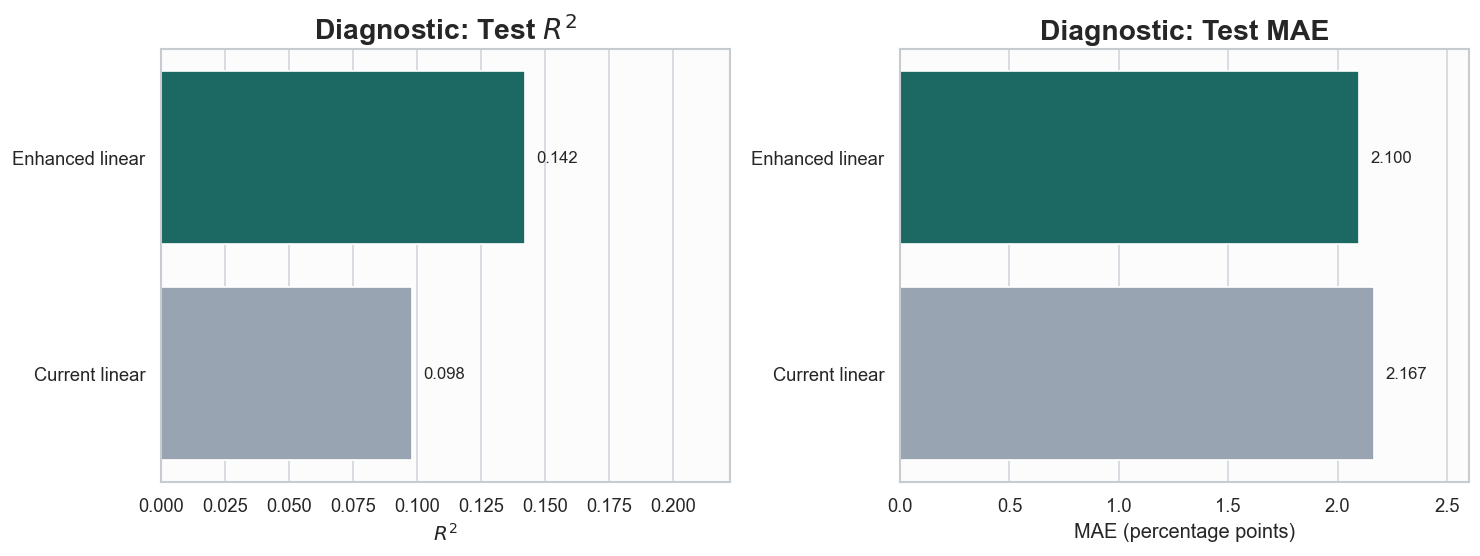

In [3]:
def make_linear_pipeline(numeric_features):
    return Pipeline(
        steps=[
            (
                "preprocessor",
                ColumnTransformer(
                    transformers=[
                        (
                            "num",
                            Pipeline(
                                steps=[
                                    ("imputer", SimpleImputer(strategy="median")),
                                    ("scaler", StandardScaler()),
                                ]
                            ),
                            numeric_features,
                        ),
                        ("cat", make_one_hot_encoder(), categorical_features),
                    ]
                ),
            ),
            ("model", LinearRegression()),
        ]
    )


persistence_rows = []
for split_name, split_df in [("Validation", val_df), ("Test", test_df)]:
    valid_rows = split_df[split_df["employment_thousands_growth_lag1_manual"].notna()].copy()
    persistence_pred = valid_rows["employment_thousands_growth_lag1_manual"]
    persistence_rows.append(
        {
            "Model": "Naive persistence benchmark",
            "Split": split_name,
            "R2": r2_score(valid_rows[target], persistence_pred),
            "RMSE": rmse(valid_rows[target], persistence_pred),
            "MAE": mean_absolute_error(valid_rows[target], persistence_pred),
        }
    )

persistence_results = pd.DataFrame(persistence_rows).round(3)
display_table(
    persistence_results,
    caption="Sanity check: a one-year persistence rule looks strong on 2019 but fails on the true held-out period",
    precision=3,
    left_align=["Model", "Split"],
)

diagnostic_rows = []
diagnostic_models = {
    "Current Linear Baseline": current_numeric_features,
    "Enhanced Linear Baseline": enhanced_numeric_features,
}

for label, numeric_features in diagnostic_models.items():
    pipeline = make_linear_pipeline(numeric_features)
    pipeline.fit(train_df[categorical_features + numeric_features], train_df[target])

    for split_name, split_df in [("Validation", val_df), ("Test", test_df)]:
        predictions = pipeline.predict(split_df[categorical_features + numeric_features])
        diagnostic_rows.append(
            {
                "Model": label,
                "Split": split_name,
                "R2": r2_score(split_df[target], predictions),
                "RMSE": rmse(split_df[target], predictions),
                "MAE": mean_absolute_error(split_df[target], predictions),
            }
        )

diagnostic_results = pd.DataFrame(diagnostic_rows).round(3)
display_table(
    diagnostic_results,
    caption="Diagnostic comparison: does a better linear feature set help?",
    precision=3,
    left_align=["Model", "Split"],
)

diagnostic_test = diagnostic_results[diagnostic_results["Split"] == "Test"].copy()
diagnostic_test["Plot label"] = diagnostic_test["Model"].map(
    {
        "Current Linear Baseline": "Current linear",
        "Enhanced Linear Baseline": "Enhanced linear",
    }
)

fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.8))

sns.barplot(
    data=diagnostic_test,
    y="Plot label",
    x="R2",
    order=["Enhanced linear", "Current linear"],
    hue="Model",
    palette=diagnostic_palette,
    legend=False,
    ax=axes[0],
)
axes[0].set_title("Diagnostic: Test $R^2$")
axes[0].set_xlabel("$R^2$")
axes[0].set_ylabel("")
axes[0].set_xlim(0, diagnostic_test["R2"].max() + 0.08)

sns.barplot(
    data=diagnostic_test,
    y="Plot label",
    x="MAE",
    order=["Enhanced linear", "Current linear"],
    hue="Model",
    palette=diagnostic_palette,
    legend=False,
    ax=axes[1],
)
axes[1].set_title("Diagnostic: Test MAE")
axes[1].set_xlabel("MAE (percentage points)")
axes[1].set_ylabel("")
axes[1].set_xlim(0, diagnostic_test["MAE"].max() * 1.20)

for ax in axes:
    xmin, xmax = ax.get_xlim()
    offset = 0.02 * (xmax - xmin)
    for patch in ax.patches:
        x = patch.get_width()
        y = patch.get_y() + patch.get_height() / 2
        ax.text(x + offset, y, f"{x:.3f}", ha="left", va="center", fontsize=10)

plt.tight_layout()
plt.show()

## 4. Training Protocol for the Final Baseline Comparison

The final three-way model comparison uses the **enhanced feature set** because the diagnostic above shows that a stronger forecasting-style baseline is more appropriate for this project.

**Feature set used by all final models**

- lagged raw satellite summaries
- lagged economic levels
- lagged economic growth terms
- metro fixed effects

**Evaluation protocol**

The project plan already specifies `2019` as the formal validation year, so we keep that split. But because a single validation year is fragile for such a small panel, we also add a **rolling-origin validation check**:

- train on years before 2016, validate on 2016
- train on years before 2017, validate on 2017
- train on years before 2018, validate on 2018

That rolling check is not meant to replace the official split. It is there to answer a research-scientist question:

> **Which model looks most stable across several historical holdout years, not just one?**

The persistence sanity check above shows exactly why this matters: a model can look excellent on `2019` and still generalize poorly to the real held-out period.

**Preprocessing**

- numeric features: median imputation
- metro identifier: one-hot encoding to create fixed effects
- scaling: applied only for linear regression
- leakage control: every predictive feature is lagged, and the split is purely time-based rather than randomly shuffled

**Parameter choices and light tuning**

The point of this notebook is to build a credible baseline, not to exhaustively optimize a small panel. So the nonlinear models are **lightly tuned rather than aggressively searched**:

| Model | Key settings | Why these settings were used |
| --- | --- | --- |
| **Linear Regression** | default linear model after scaling | maximally interpretable benchmark |
| **Random Forest** | `n_estimators=400`, `max_depth=6`, `min_samples_leaf=3` | enough flexibility to capture interactions while limiting overfitting |
| **Gradient Boosting** | `n_estimators=100`, `learning_rate=0.05`, `max_depth=2` | shallow boosting setup that stays conservative on a small panel |

**Evaluation metrics**

- **R²**: how much variation in employment growth is explained
- **RMSE**: penalizes larger forecasting errors more heavily
- **MAE**: easiest to interpret as average prediction error in percentage points

In [4]:
def make_tree_pipeline(numeric_features, estimator):
    return Pipeline(
        steps=[
            (
                "preprocessor",
                ColumnTransformer(
                    transformers=[
                        (
                            "num",
                            Pipeline(steps=[("imputer", SimpleImputer(strategy="median"))]),
                            numeric_features,
                        ),
                        ("cat", make_one_hot_encoder(), categorical_features),
                    ]
                ),
            ),
            ("model", estimator),
        ]
    )


candidate_models = {
    "Linear Regression (fixed effects)": make_linear_pipeline(enhanced_numeric_features),
    "Random Forest Regressor": make_tree_pipeline(
        enhanced_numeric_features,
        RandomForestRegressor(
            n_estimators=400,
            max_depth=6,
            min_samples_leaf=3,
            random_state=42,
        ),
    ),
    "Gradient Boosting Regressor": make_tree_pipeline(
        enhanced_numeric_features,
        GradientBoostingRegressor(
            n_estimators=100,
            learning_rate=0.05,
            max_depth=2,
            random_state=42,
        ),
    ),
}

rolling_years = [2016, 2017, 2018]

rows = []
rolling_detail_rows = []
fitted_models = {}
prediction_store = {}

for model_name, pipeline in candidate_models.items():
    rolling_scores = []
    for holdout_year in rolling_years:
        rolling_train = panel_df[(panel_df["year"] < holdout_year) & (panel_df["split"] == "train")].copy()
        rolling_valid = panel_df[(panel_df["year"] == holdout_year) & (panel_df["split"] == "train")].copy()

        pipeline.fit(
            rolling_train[categorical_features + enhanced_numeric_features],
            rolling_train[target],
        )
        rolling_pred = pipeline.predict(
            rolling_valid[categorical_features + enhanced_numeric_features]
        )
        rolling_scores.append(
            {
                "year": holdout_year,
                "r2": r2_score(rolling_valid[target], rolling_pred),
                "rmse": rmse(rolling_valid[target], rolling_pred),
                "mae": mean_absolute_error(rolling_valid[target], rolling_pred),
            }
        )
        rolling_detail_rows.append(
            {
                "Model": model_name,
                "Holdout year": holdout_year,
                "R2": r2_score(rolling_valid[target], rolling_pred),
                "RMSE": rmse(rolling_valid[target], rolling_pred),
                "MAE": mean_absolute_error(rolling_valid[target], rolling_pred),
            }
        )

    rolling_df = pd.DataFrame(rolling_scores)

    pipeline.fit(
        train_df[categorical_features + enhanced_numeric_features],
        train_df[target],
    )
    fitted_models[model_name] = pipeline

    val_pred = pipeline.predict(val_df[categorical_features + enhanced_numeric_features])
    test_pred = pipeline.predict(test_df[categorical_features + enhanced_numeric_features])

    prediction_store[(model_name, "Validation")] = val_pred
    prediction_store[(model_name, "Test")] = test_pred

    rows.append(
        {
            "Model": model_name,
            "Rolling CV Mean R2": rolling_df["r2"].mean(),
            "Rolling CV Mean MAE": rolling_df["mae"].mean(),
            "Validation R2": r2_score(val_df[target], val_pred),
            "Validation MAE": mean_absolute_error(val_df[target], val_pred),
            "Test R2": r2_score(test_df[target], test_pred),
            "Test MAE": mean_absolute_error(test_df[target], test_pred),
            "Test RMSE": rmse(test_df[target], test_pred),
        }
    )

comparison_results = pd.DataFrame(rows).sort_values(
    ["Rolling CV Mean MAE", "Validation MAE", "Test MAE"]
).reset_index(drop=True)

selected_model_name = comparison_results.iloc[0]["Model"]
comparison_results_display = comparison_results.copy()
comparison_results_display.insert(
    1,
    "Status",
    comparison_results_display["Model"].map(
        lambda value: "Selected baseline" if value == selected_model_name else ""
    ),
)
display_table(
    comparison_results_display.round(3),
    caption="Final baseline comparison",
    precision=3,
    left_align=["Model", "Status"],
    highlight_rows=[comparison_results_display.index[0]],
)

selection_summary = pd.DataFrame(
    [
        {
            "Selected model": selected_model_name,
            "Selection rule": "Lowest rolling-CV mean MAE, with 2019 validation MAE as tie-breaker",
        }
    ]
)
display_table(
    selection_summary,
    caption="Selection summary",
    precision=3,
    left_align=["Selected model", "Selection rule"],
)

rolling_results = pd.DataFrame(rolling_detail_rows)
rolling_mae_table = (
    rolling_results.pivot(index="Holdout year", columns="Model", values="MAE")
    .reset_index()
    .round(3)
)
display_table(
    rolling_mae_table,
    caption="Rolling-origin validation MAE by holdout year",
    precision=3,
    left_align=["Holdout year"],
)

Model,Status,Rolling CV Mean R2,Rolling CV Mean MAE,Validation R2,Validation MAE,Test R2,Test MAE,Test RMSE
Random Forest Regressor,Selected baseline,-0.252,0.854,0.246,0.565,0.146,1.933,2.765
Gradient Boosting Regressor,,-0.305,0.862,0.202,0.567,0.165,1.955,2.733
Linear Regression (fixed effects),,-1.122,1.129,-4.777,1.605,0.142,2.100,2.771


Selected model,Selection rule
Random Forest Regressor,"Lowest rolling-CV mean MAE, with 2019 validation MAE as tie-breaker"


Holdout year,Gradient Boosting Regressor,Linear Regression (fixed effects),Random Forest Regressor
2016,1.404,1.663,1.408
2017,0.438,0.908,0.507
2018,0.744,0.818,0.647


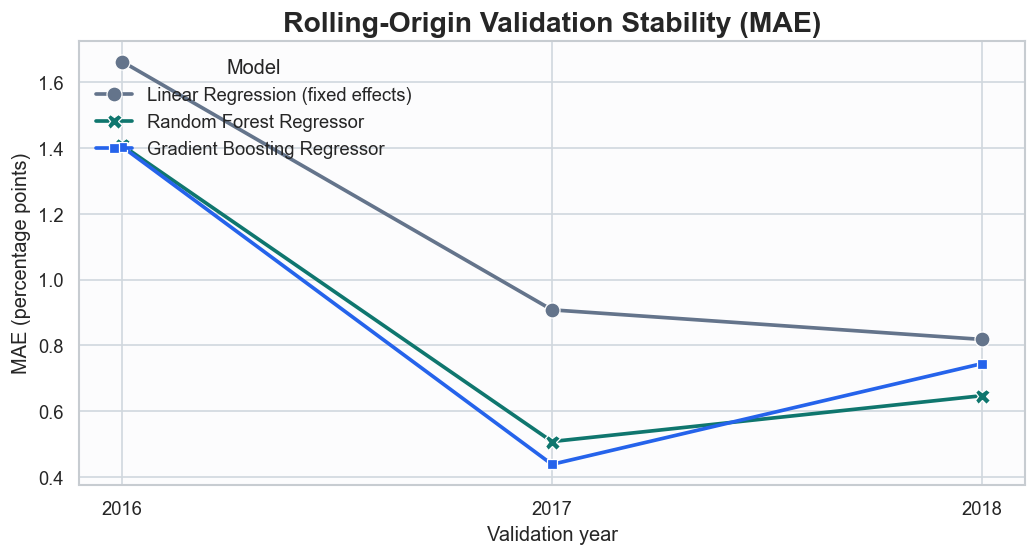

In [5]:
plt.figure(figsize=(8.8, 4.8))
ax = sns.lineplot(
    data=rolling_results,
    x="Holdout year",
    y="MAE",
    hue="Model",
    style="Model",
    markers=True,
    dashes=False,
    palette=model_palette,
    linewidth=2.2,
    markersize=9,
)
ax.set_title("Rolling-Origin Validation Stability (MAE)")
ax.set_xlabel("Validation year")
ax.set_ylabel("MAE (percentage points)")
ax.set_xticks(sorted(rolling_results["Holdout year"].unique()))
ax.legend(title="Model", loc="upper left")
plt.tight_layout()
plt.show()

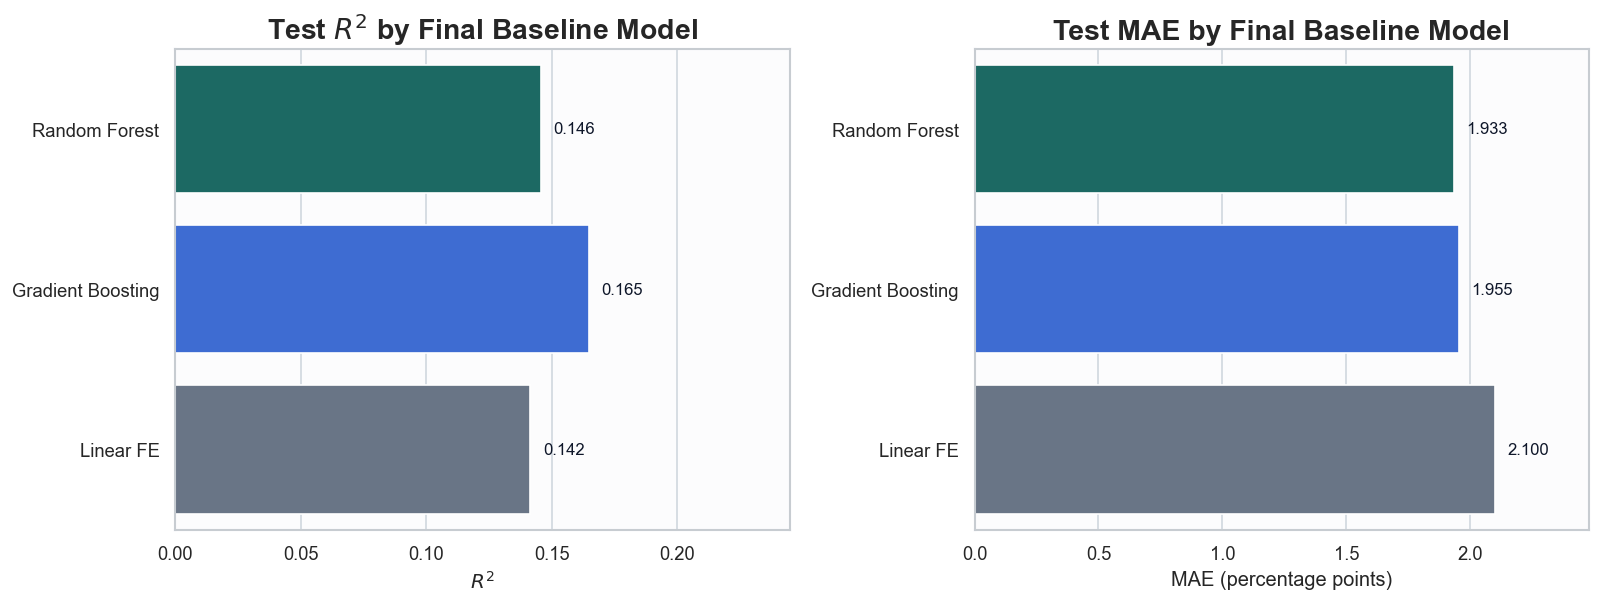

In [6]:
def annotate_bars(ax, decimals=3):
    xmin, xmax = ax.get_xlim()
    offset = 0.02 * (xmax - xmin)
    for patch in ax.patches:
        value = patch.get_width()
        x = value
        y = patch.get_y() + patch.get_height() / 2
        ax.text(
            x + offset,
            y,
            f"{value:.{decimals}f}",
            ha="left",
            va="center",
            fontsize=10,
            color="#0f172a",
        )


plot_order = comparison_results["Model"].tolist()
plot_labels = {
    "Random Forest Regressor": "Random Forest",
    "Gradient Boosting Regressor": "Gradient Boosting",
    "Linear Regression (fixed effects)": "Linear FE",
}
comparison_plot = comparison_results.copy()
comparison_plot["Plot label"] = comparison_plot["Model"].map(plot_labels)

fig, axes = plt.subplots(1, 2, figsize=(13.5, 5.2))

sns.barplot(
    data=comparison_plot,
    y="Plot label",
    x="Test R2",
    order=[plot_labels[name] for name in plot_order],
    hue="Model",
    palette=model_palette,
    legend=False,
    ax=axes[0],
)
axes[0].set_title("Test $R^2$ by Final Baseline Model")
axes[0].set_xlabel("$R^2$")
axes[0].set_ylabel("")
axes[0].set_xlim(0, comparison_results["Test R2"].max() + 0.08)
annotate_bars(axes[0], decimals=3)

sns.barplot(
    data=comparison_plot,
    y="Plot label",
    x="Test MAE",
    order=[plot_labels[name] for name in plot_order],
    hue="Model",
    palette=model_palette,
    legend=False,
    ax=axes[1],
)
axes[1].set_title("Test MAE by Final Baseline Model")
axes[1].set_xlabel("MAE (percentage points)")
axes[1].set_ylabel("")
axes[1].set_xlim(0, comparison_results["Test MAE"].max() * 1.18)
annotate_bars(axes[1], decimals=3)

plt.tight_layout()
plt.show()

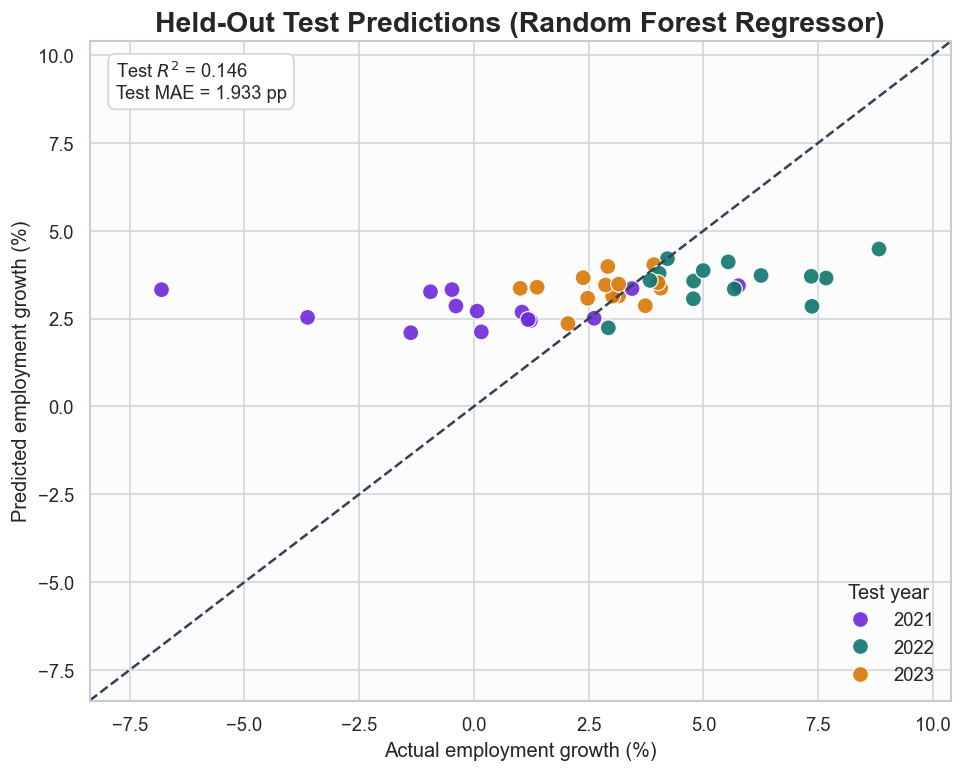

In [7]:
selected_model = fitted_models[selected_model_name]
selected_test_pred = prediction_store[(selected_model_name, "Test")]
selected_row = comparison_results[comparison_results["Model"] == selected_model_name].iloc[0]

prediction_df = test_df[["metro", "year", target]].copy()
prediction_df["prediction"] = selected_test_pred

plot_min = min(prediction_df[target].min(), prediction_df["prediction"].min())
plot_max = max(prediction_df[target].max(), prediction_df["prediction"].max())
padding = 0.10 * (plot_max - plot_min)
lower = plot_min - padding
upper = plot_max + padding

plt.figure(figsize=(8.2, 6.6))
ax = sns.scatterplot(
    data=prediction_df,
    x=target,
    y="prediction",
    hue="year",
    palette=year_palette,
    s=92,
    alpha=0.9,
    edgecolor="white",
    linewidth=0.8,
)
ax.plot([lower, upper], [lower, upper], linestyle="--", linewidth=1.5, color="#334155")
ax.set_xlim(lower, upper)
ax.set_ylim(lower, upper)
ax.set_xlabel("Actual employment growth (%)")
ax.set_ylabel("Predicted employment growth (%)")
ax.set_title(f"Held-Out Test Predictions ({selected_model_name})")
ax.text(
    0.03,
    0.97,
    f"Test $R^2$ = {selected_row['Test R2']:.3f}\nTest MAE = {selected_row['Test MAE']:.3f} pp",
    transform=ax.transAxes,
    ha="left",
    va="top",
    fontsize=11,
    bbox=dict(boxstyle="round,pad=0.4", facecolor="white", edgecolor="#cbd5e1"),
)
ax.legend(title="Test year", loc="lower right")
plt.tight_layout()
plt.show()

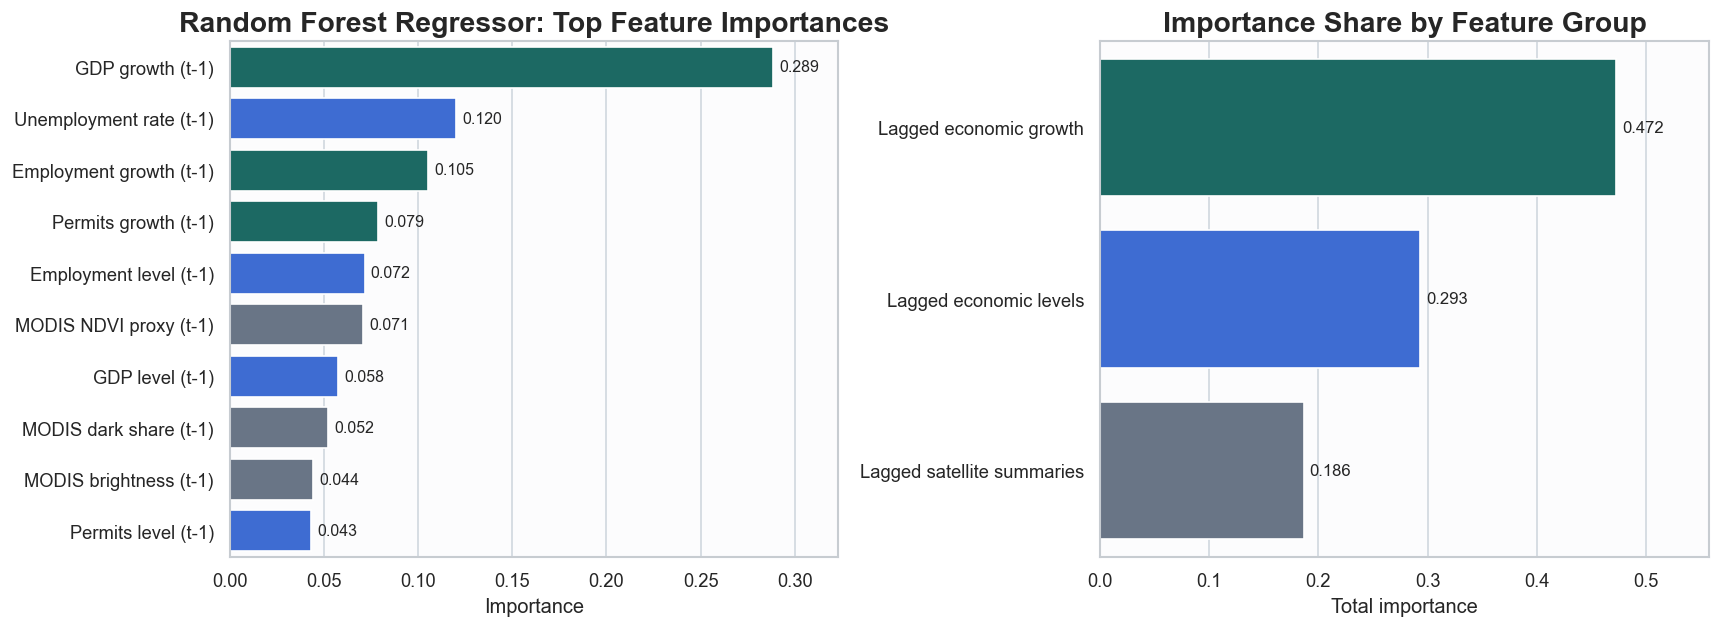

display_feature,group,importance
GDP growth (t-1),Lagged economic growth,0.2885
Unemployment rate (t-1),Lagged economic levels,0.1201
Employment growth (t-1),Lagged economic growth,0.1052
Permits growth (t-1),Lagged economic growth,0.0787
Employment level (t-1),Lagged economic levels,0.0717
MODIS NDVI proxy (t-1),Lagged satellite summaries,0.0709
GDP level (t-1),Lagged economic levels,0.0576
MODIS dark share (t-1),Lagged satellite summaries,0.0522
MODIS brightness (t-1),Lagged satellite summaries,0.0442
Permits level (t-1),Lagged economic levels,0.0434


group,importance
Lagged economic growth,0.4724
Lagged economic levels,0.2928
Lagged satellite summaries,0.1864


In [8]:
def get_feature_names(preprocessor):
    names = []
    for transformer_name, transformer, cols in preprocessor.transformers_:
        if transformer_name == "num":
            names.extend(list(cols))
        elif transformer_name == "cat":
            if hasattr(transformer, "get_feature_names_out"):
                try:
                    cat_names = transformer.get_feature_names_out(cols)
                except TypeError:
                    cat_names = transformer.get_feature_names(cols)
            else:
                cat_names = transformer.get_feature_names(cols)
            names.extend(list(cat_names))
    return names


def feature_group(feature_name):
    if "growth_lag1" in feature_name:
        return "Lagged economic growth"
    if feature_name in [
        "gdp_millions_lag1",
        "employment_thousands_lag1",
        "unemployment_rate_lag1",
        "total_permits_lag1",
    ]:
        return "Lagged economic levels"
    return "Lagged satellite summaries"


selected_estimator = selected_model.named_steps["model"]
preprocessor = selected_model.named_steps["preprocessor"]

feature_label_map = {
    "gdp_millions_growth_lag1_manual": "GDP growth (t-1)",
    "employment_thousands_growth_lag1_manual": "Employment growth (t-1)",
    "total_permits_growth_lag1_manual": "Permits growth (t-1)",
    "gdp_millions_lag1": "GDP level (t-1)",
    "employment_thousands_lag1": "Employment level (t-1)",
    "unemployment_rate_lag1": "Unemployment rate (t-1)",
    "total_permits_lag1": "Permits level (t-1)",
    "modis_brightness_mean_lag1_manual": "MODIS brightness (t-1)",
    "modis_ndvi_proxy_mean_lag1_manual": "MODIS NDVI proxy (t-1)",
    "modis_dark_frac_lag1_manual": "MODIS dark share (t-1)",
    "viirs_mean_lag1_manual": "VIIRS mean (t-1)",
    "viirs_lit_frac_lag1_manual": "VIIRS lit share (t-1)",
    "viirs_bright_frac_lag1_manual": "VIIRS bright share (t-1)",
    "viirs_gini_lag1_manual": "VIIRS inequality (t-1)",
}

if hasattr(selected_estimator, "feature_importances_"):
    importance_df = pd.DataFrame(
        {
            "feature": get_feature_names(preprocessor),
            "importance": selected_estimator.feature_importances_,
        }
    )
    importance_df = importance_df[~importance_df["feature"].str.startswith("metro_")].copy()
    importance_df["group"] = importance_df["feature"].map(feature_group)
    importance_df["display_feature"] = importance_df["feature"].map(
        lambda value: feature_label_map.get(value, value)
    )

    top_importance = importance_df.sort_values("importance", ascending=False).head(10).copy()
    group_importance = (
        importance_df.groupby("group", as_index=False)["importance"]
        .sum()
        .sort_values("importance", ascending=False)
    )

    fig, axes = plt.subplots(1, 2, figsize=(14.5, 5.4))

    sns.barplot(
        data=top_importance,
        x="importance",
        y="display_feature",
        hue="group",
        palette=group_palette,
        legend=False,
        ax=axes[0],
    )
    axes[0].set_title(f"{selected_model_name}: Top Feature Importances")
    axes[0].set_xlabel("Importance")
    axes[0].set_ylabel("")
    xmax = top_importance["importance"].max() * 1.12
    axes[0].set_xlim(0, xmax)
    for patch in axes[0].patches:
        value = patch.get_width()
        y = patch.get_y() + patch.get_height() / 2
        axes[0].text(value + 0.01 * xmax, y, f"{value:.3f}", va="center", ha="left", fontsize=9.5)

    sns.barplot(
        data=group_importance,
        x="importance",
        y="group",
        hue="group",
        palette=group_palette,
        legend=False,
        ax=axes[1],
    )
    axes[1].set_title("Importance Share by Feature Group")
    axes[1].set_xlabel("Total importance")
    axes[1].set_ylabel("")
    axes[1].set_xlim(0, group_importance["importance"].max() * 1.18)
    for patch in axes[1].patches:
        value = patch.get_width()
        y = patch.get_y() + patch.get_height() / 2
        axes[1].text(
            value + 0.01 * axes[1].get_xlim()[1],
            y,
            f"{value:.3f}",
            va="center",
            ha="left",
            fontsize=10,
        )

    plt.tight_layout()
    plt.show()

    display_table(
        top_importance[["display_feature", "group", "importance"]].reset_index(drop=True).round(4),
        caption="Top feature importances for the selected model",
        precision=4,
        left_align=["display_feature", "group"],
    )
    display_table(
        group_importance.round(4),
        caption="Importance share by feature group",
        precision=4,
        left_align=["group"],
    )

## 5. Initial Results and Alignment with Expectations

The critical review changes the story in an important way.

**What improved**

- The naive persistence check shows why **`2019` alone cannot determine model choice**:
  it posts a validation **MAE of about 0.272** but then deteriorates to a test **MAE of about 3.645** on `2021-2023`.
- Adding lagged growth terms improves the linear baseline over the earlier formulation.
  In the test set, the linear benchmark moves from roughly **R² = 0.098 / MAE = 2.167** to **R² = 0.142 / MAE = 2.100**.
- The nonlinear models improve further, especially in **MAE**, which is the most directly interpretable forecasting metric here.
- The selected model is chosen by **stability** rather than by the single highest test score.

**How the initial results line up with expectations**

These results are broadly consistent with the EDA and the project objective:

- we expected **raw satellite summaries alone** to be limited, and the diagnostic confirms that they are not enough by themselves;
- we expected **past economic dynamics** to matter for forecasting future change, and adding lagged growth terms does help;
- we expected a nonlinear 109B model to be a useful comparison, and both tree ensembles are competitive with or better than the linear benchmark.

The selected **Random Forest** is not chosen because it has the absolute best test `R²`; instead, it is chosen because it gives the most balanced story across:

- rolling-origin validation stability,
- 2019 validation performance,
- and held-out test MAE.

That is a better match to the project objective than picking a model solely because it looks best on one held-out slice.

**What the improvement means scientifically**

The stronger baseline does **not** mean the proposal is already solved. In fact, the feature-importance breakdown shows that much of the predictive gain comes from **lagged economic dynamics**, not from the raw satellite summaries alone. That is a useful research finding:

- the problem has real autoregressive structure,
- the current satellite-summary features add only limited extra signal,
- and the project still needs the richer **built-up footprint / urban-form features** from the later stages.

In other words, the improved baseline is valuable precisely because it is hard to beat honestly. Any later image-derived feature set should be evaluated against **this** stronger benchmark, not against the weaker earlier one.

## 6. Conformance, Remaining Gaps, and Next Steps

This revised notebook now conforms more closely to both the proposal and `MODELING_NEXT_STEPS.md`:

- it uses the project's **time-aware train / val / test split**
- it predicts a **future economic change target**
- it includes a simple **linear fixed-effects-style baseline**
- it includes Stat 109B nonlinear baselines
- it evaluates with **R², RMSE, and MAE**
- it explicitly treats this as a **raw-pixel baseline before GHSL-derived spatial features**

Just as importantly, it is also honest about what remains unresolved:

- the proposal's main scientific claim is about **urban expansion / built-up growth**
- the current panel still lacks those explicit spatial features
- so this notebook should be read as the **best current baseline**, not the final research result

The most important remaining gaps are:

1. the notebook currently covers **one outcome** (`employment_thousands_growth`) rather than the full target set in the proposal;
2. the current predictors are still **raw satellite summaries**, not the more meaningful urban-form features promised in the proposal;
3. the panel is small, so apparent wins on a single year should always be interpreted cautiously.

The clean next step sequence is therefore:

| Next step | Why it matters | What success would look like |
| --- | --- | --- |
| **Generate GHSL / built-up features** | This is the missing scientific core of the proposal. | A metro-year panel with built-up area, compactness, infill/sprawl, and change metrics. |
| **Run the planned feature-set ablations** | This directly tests the Stage 3 plan in `MODELING_NEXT_STEPS.md`. | Compare raw-only vs spatial-only vs combined vs spatial-plus-economic-lags. |
| **Replicate the same benchmark structure for GDP and permits** | This broadens the milestone from one outcome to the proposal's wider economic story. | The exact same train/val/test logic applied to additional targets. |
| **Add sensitivity checks across metros or regions** | This tests whether performance is driven by a few cities. | Similar conclusions under leave-one-metro-out or expanded geography checks. |

That makes this notebook a strong milestone deliverable: it closes the **raw-pixel baseline** stage cleanly, and it also sets a clear bar for the next modeling stage to beat.